In [ ]:
#PIPELINE
  #Includes:
    #Preprocessing
    #PCA + Scree Plot
    #KMeans + Elbow Plot
    #Cluster Visualization
    #Model Comparison
    #Hyperparameter Tuning
    #FREQ Model
    #CM Model
    #Final CHARGE
    #5-Fold CV

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

In [2]:
#LOAD DATA

from google.colab import drive
drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/DS Project/"

x_train = pd.read_csv(base_path + "train_input_Z61KlZo.csv")
y_train = pd.read_csv(base_path + "train_output_DzPxaPY.csv")
x_test = pd.read_csv(base_path + "test_input_5qJzHrr.csv")

print("Files loaded successfully!")

print("Initial shape:", x_train.shape)

Mounted at /content/drive


/tmp/ipykernel_4371/923932928.py:8: DtypeWarning: Columns (16,17,29,30,31,126,128,129,132,133,135,138,371) have mixed types. Specify dtype option on import or set low_memory=False.
  x_train = pd.read_csv(base_path + "train_input_Z61KlZo.csv")
/tmp/ipykernel_4371/923932928.py:10: DtypeWarning: Columns (16,17,29,30,31,126,128,129,132,133,135,138,371) have mixed types. Specify dtype option on import or set low_memory=False.
  x_test = pd.read_csv(base_path + "test_input_5qJzHrr.csv")


Files loaded successfully!
Initial shape: (383610, 374)


In [3]:
#CLEANING

constant_cols = [c for c in x_train.columns if x_train[c].nunique() <= 1]
x_train.drop(columns=constant_cols, inplace=True)

x_train = x_train.drop_duplicates()

binary_cols = [
    col for col in x_train.columns
    if set(x_train[col].dropna().unique()).issubset({0,1,0.0,1.0})
]

raw_cat = [
    col for col in x_train.columns
    if 1 < x_train[col].dropna().nunique() <= 14
    and col not in binary_cols
]

cat_cols = list(
    set(raw_cat + x_train.select_dtypes(include=['object']).columns.tolist())
)

numerical_cols = [
    col for col in x_train.columns
    if col not in cat_cols and col not in binary_cols
]

for col in numerical_cols:
    x_train[col] = x_train[col].fillna(x_train[col].median())

for col in cat_cols:
    x_train[col] = x_train[col].astype(str).fillna("Missing")

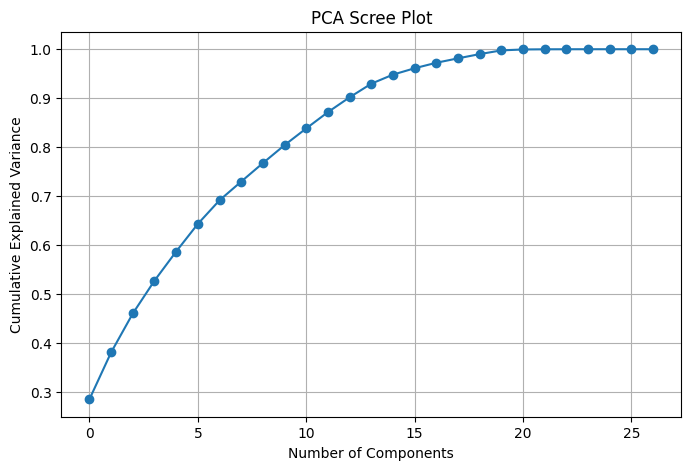

Number of PCA components: 13


/tmp/ipykernel_4371/189158057.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  x_train[f"PCA_{i}"] = pca_features[:, i]
/tmp/ipykernel_4371/189158057.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  x_train[f"PCA_{i}"] = pca_features[:, i]
/tmp/ipykernel_4371/189158057.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, us

In [4]:
#PCA(Dimensionality Reduction)

scaler = StandardScaler()
scaled_num = scaler.fit_transform(x_train[numerical_cols])

pca_full = PCA()
pca_full.fit(scaled_num)

#Scree Plot
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Scree Plot")
plt.grid()
plt.show()

#Keep 90% variance
pca = PCA(n_components=0.90, random_state=42)
pca_features = pca.fit_transform(scaled_num)

print("Number of PCA components:", pca_features.shape[1])

#Add PCA features
for i in range(pca_features.shape[1]):
    x_train[f"PCA_{i}"] = pca_features[:, i]


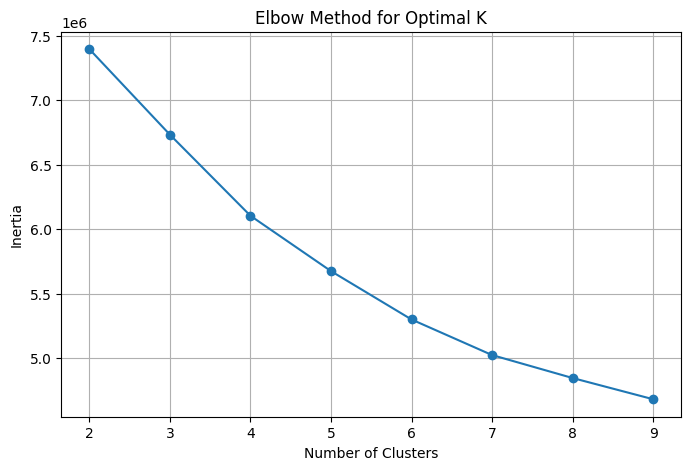

/tmp/ipykernel_4371/2208615419.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  x_train["Cluster"] = clusters


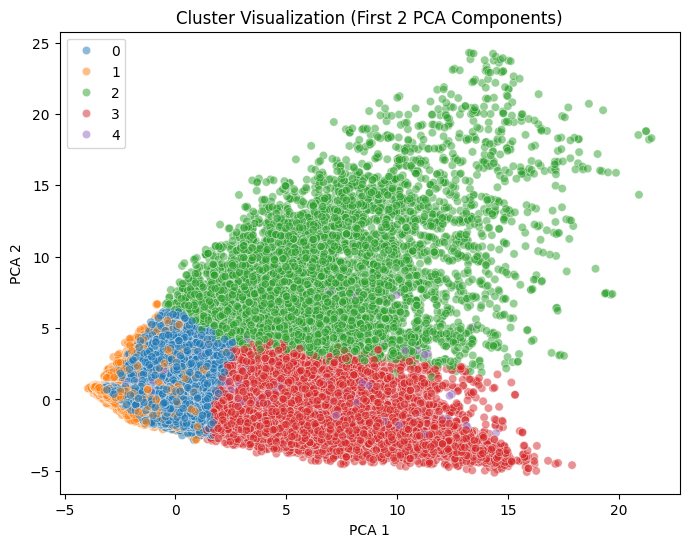

In [5]:
#KMEANS CLUSTERING

#Elbow Method
inertia = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(pca_features)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.grid()
plt.show()

#Choose 5 clusters
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(pca_features)

x_train["Cluster"] = clusters
cat_cols.append("Cluster")

#Cluster Visualization (First 2 PCA components)
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=pca_features[:,0],
    y=pca_features[:,1],
    hue=clusters,
    palette="tab10",
    alpha=0.5
)
plt.title("Cluster Visualization (First 2 PCA Components)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.show()

In [ ]:
#MODEL COMPARISON

#Encode x_train once
from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

encoder_full = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
x_train_enc = x_train.copy()
x_train_enc[cat_cols] = encoder_full.fit_transform(x_train_enc[cat_cols])
x_train_enc = x_train_enc.fillna(0)

col_names = list(x_train_enc.columns)
annee_idx = col_names.index("ANNEE_ASSURANCE")
X_np     = x_train_enc.values.astype(np.float32)
y_freq   = y_train["FREQ"].values.astype(np.float32)
y_cm     = y_train["CM"].clip(lower=0).values.astype(np.float32)
y_charge = y_train["CHARGE"].clip(lower=0).values.astype(np.float32)

kf_comp = KFold(n_splits=3, shuffle=True, random_state=42)  #3 folds for speed

results = {"Ridge": [], "RandomForest": [], "XGBoost": []}

CM_PARAMS = dict(
    objective="reg:squarederror",
    n_estimators=300,
    max_depth=8, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1,
    tree_method="hist", device="cuda",
)

for fold, (train_idx, val_idx) in enumerate(kf_comp.split(X_np)):
    print(f"\n===== Fold {fold+1} =====")

    X_tr  = X_np[train_idx]
    X_val = X_np[val_idx]
    yf_tr       = y_freq[train_idx]
    yc_tr       = y_cm[train_idx]
    ycharge_val = y_charge[val_idx]
    annee_val   = X_val[:, annee_idx]

    #Shared CM model
    mask_cm = yc_tr > 0
    cm_model = XGBRegressor(**CM_PARAMS)
    cm_model.fit(X_tr[mask_cm], np.log1p(yc_tr[mask_cm]))
    cm_pred = np.maximum(np.expm1(cm_model.predict(X_val)), 0)
    del cm_model; gc.collect()

    #Ridge
    print("  Ridge...")
    ridge = Ridge(alpha=1.0, solver='saga', max_iter=500)
    ridge.fit(X_tr, yf_tr)
    freq_r = np.maximum(ridge.predict(X_val), 0)
    rmse_r = np.sqrt(mean_squared_error(ycharge_val,
                     np.maximum(freq_r * cm_pred * annee_val, 0)))
    results["Ridge"].append(rmse_r)
    print(f"  Ridge RMSE: {rmse_r:.2f}")
    del ridge; gc.collect()

    #Random Forest
    print("  Random Forest...")
    rf = RandomForestRegressor(
        n_estimators=200, max_depth=10,
        max_samples=0.2,   # 20% rows — key for speed
        random_state=42, n_jobs=-1,
    )
    rf.fit(X_tr, yf_tr)
    freq_rf = np.maximum(rf.predict(X_val), 0)
    rmse_rf = np.sqrt(mean_squared_error(ycharge_val,
                      np.maximum(freq_rf * cm_pred * annee_val, 0)))
    results["RandomForest"].append(rmse_rf)
    print(f"  RF RMSE: {rmse_rf:.2f}")
    del rf; gc.collect()

    #XGBoost
    print("  XGBoost...")
    xgb = XGBRegressor(
        objective="count:poisson",
        n_estimators=500, max_depth=6,
        learning_rate=0.05, subsample=0.8,
        colsample_bytree=0.8, random_state=42,
        n_jobs=-1, tree_method="hist", device="cuda",
    )
    xgb.fit(X_tr, yf_tr)
    freq_xgb = np.maximum(xgb.predict(X_val), 0)
    rmse_xgb = np.sqrt(mean_squared_error(ycharge_val,
                       np.maximum(freq_xgb * cm_pred * annee_val, 0)))
    results["XGBoost"].append(rmse_xgb)
    print(f"  XGBoost RMSE: {rmse_xgb:.2f}")
    del xgb, X_tr, X_val; gc.collect()

print(f"\n{'='*50}")
print("FINAL COMPARISON RESULTS (3-fold CV):")
print(f"{'='*50}")
for model, scores in results.items():
    print(f"{model:15s}  RMSE: {np.mean(scores):,.1f}  (+/- {np.std(scores):,.1f})")



===== Fold 1 =====
  Ridge...
  Ridge RMSE: 6913.69
  Random Forest...
  RF RMSE: 6914.30
  XGBoost...
  XGBoost RMSE: 6913.63

===== Fold 2 =====
  Ridge...
  Ridge RMSE: 6703.06
  Random Forest...
  RF RMSE: 6705.18
  XGBoost...
  XGBoost RMSE: 6701.96

===== Fold 3 =====
  Ridge...
  Ridge RMSE: 6782.30
  Random Forest...
  RF RMSE: 6782.12
  XGBoost...
  XGBoost RMSE: 6781.32

FINAL COMPARISON RESULTS (3-fold CV):
Ridge            RMSE: 6,799.7  (+/- 86.9)
RandomForest     RMSE: 6,800.5  (+/- 86.4)
XGBoost          RMSE: 6,799.0  (+/- 87.3)


In [ ]:
#HYPERPARAMETER TUNING
print(f"\n{'='*50}")
print("HYPERPARAMETER TUNING — XGBoost FREQ (1 fold)")
print(f"{'='*50}")

train_idx, val_idx = next(iter(KFold(n_splits=5, shuffle=True,
                                      random_state=42).split(X_np)))
X_tr  = X_np[train_idx];  X_val = X_np[val_idx]
yf_tr = y_freq[train_idx]; yc_tr = y_cm[train_idx]
ycharge_val = y_charge[val_idx]; annee_val = X_val[:, annee_idx]

mask_cm = yc_tr > 0
cm_fixed = XGBRegressor(**CM_PARAMS)
cm_fixed.fit(X_tr[mask_cm], np.log1p(yc_tr[mask_cm]))
cm_pred_fixed = np.maximum(np.expm1(cm_fixed.predict(X_val)), 0)
del cm_fixed; gc.collect()

tuning_grid = {
    "max_depth":        [4, 6, 8],
    "learning_rate":    [0.01, 0.05, 0.10],
    "subsample":        [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
}

base_params = dict(
    objective="count:poisson", n_estimators=300,
    max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1,
    tree_method="hist", device="cuda",
)

print(f"\n{'Parameter':<20} {'Value':<10} {'RMSE':>10}")
print("-" * 44)

for param, values in tuning_grid.items():
    best_val, best_rmse = None, 9e9
    for v in values:
        params = base_params.copy()
        params[param] = v
        m = XGBRegressor(**params)
        m.fit(X_tr, yf_tr)
        freq_p = np.maximum(m.predict(X_val), 0)
        charge_p = np.maximum(freq_p * cm_pred_fixed * annee_val, 0)
        rmse = np.sqrt(mean_squared_error(ycharge_val, charge_p))
        marker = " <-- best" if rmse < best_rmse else ""
        print(f"  {param:<18} {str(v):<10} {rmse:>10,.1f}{marker}")
        if rmse < best_rmse:
            best_rmse = rmse
            best_val = v
        del m; gc.collect()
    base_params[param] = best_val
    print()

print("Best params found:")
for k, v in base_params.items():
    print(f"  {k}: {v}")

del X_tr, X_val; gc.collect()


HYPERPARAMETER TUNING — XGBoost FREQ (1 fold)

Parameter            Value            RMSE
--------------------------------------------
  max_depth          4             7,043.6 <-- best
  max_depth          6             7,043.6 <-- best
  max_depth          8             7,043.7

  learning_rate      0.01          7,043.8 <-- best
  learning_rate      0.05          7,043.6 <-- best
  learning_rate      0.1           7,043.6 <-- best

  subsample          0.6           7,043.5 <-- best
  subsample          0.8           7,043.6
  subsample          1.0           7,043.6

  colsample_bytree   0.6           7,043.7 <-- best
  colsample_bytree   0.8           7,043.5 <-- best
  colsample_bytree   1.0           7,043.5

Best params found:
  objective: count:poisson
  n_estimators: 300
  max_depth: 6
  learning_rate: 0.1
  subsample: 0.6
  colsample_bytree: 0.8
  random_state: 42
  n_jobs: -1
  tree_method: hist
  device: cuda


0

In [ ]:
#PREPARE TARGETS

data = x_train.copy()

data["FREQ"] = y_train["FREQ"]
data["CM"] = y_train["CM"].clip(lower=0)
data["CHARGE"] = y_train["CHARGE"].clip(lower=0)

X = data.drop(columns=["FREQ","CM","CHARGE"])
y_freq = data["FREQ"]
y_cm = data["CM"]
y_charge = data["CHARGE"]


#5-FOLD CROSS VALIDATION

kf = KFold(n_splits=5, shuffle=True, random_state=42)

rmse_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):

    print(f"\n===== Fold {fold+1} =====")

    X_train_split = X.iloc[train_idx].copy()
    X_val = X.iloc[val_idx].copy()

    y_freq_tr = y_freq.iloc[train_idx]
    y_cm_tr = y_cm.iloc[train_idx]
    y_charge_val = y_charge.iloc[val_idx]

    #Encode categorical
    encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

    X_train_split[cat_cols] = encoder.fit_transform(X_train_split[cat_cols])
    X_val[cat_cols] = encoder.transform(X_val[cat_cols])

    X_train_split = X_train_split.fillna(0)
    X_val = X_val.fillna(0)


    #Frequency Model
    freq_model = XGBRegressor(
        objective="count:poisson",
        n_estimators=1200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )

    freq_model.fit(X_train_split, y_freq_tr)
    freq_pred = freq_model.predict(X_val)


    #Severity Model
    mask = y_freq_tr > 0
    y_cm_log = np.log1p(y_cm_tr[mask])

    cm_model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=1500,
        max_depth=8,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )

    cm_model.fit(X_train_split[mask], y_cm_log)

    cm_log_pred = cm_model.predict(X_val)
    cm_pred = np.expm1(cm_log_pred)
    cm_pred = np.maximum(cm_pred, 0)


    #Final Charge
    final_pred = freq_pred * cm_pred * X_val["ANNEE_ASSURANCE"]

    rmse = np.sqrt(mean_squared_error(y_charge_val, final_pred))
    print("Fold RMSE:", round(rmse,2))

    rmse_scores.append(rmse)

print("\nAverage CV RMSE:", round(np.mean(rmse_scores),2))


===== Fold 1 =====
Fold RMSE: 7044.76

===== Fold 2 =====
Fold RMSE: 6984.65

===== Fold 3 =====
Fold RMSE: 7156.34

===== Fold 4 =====
Fold RMSE: 6333.84

===== Fold 5 =====
Fold RMSE: 6431.9

Average CV RMSE: 6790.3
